# Regression

**If you are a Colab user**

If you use Google Colab, you can uncomment the following cell to mount your Google Drive to Colab.
After that, Colab can read and write files and data in your Google Drive.

Please change the current directory to the folder where you saved your notebook and
data folder. For example, I saved my Colab files and data in the following location:

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

#%cd /content/drive/MyDrive/Colab\ Notebooks

**Set up standards for the remainder of the notebook**

In [2]:
## Import libraries and tools ##

import numpy as np # linear algebra
import pandas as pd # data processing and CSV file I/O

import scipy as sp # scientific and technical computing
from scipy import stats

import math

#from matplotlib import rcParams
import matplotlib.pyplot as plt # visualization
import seaborn as sns

# We primarily use sklearn in this notebook
import sklearn
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, ElasticNet, ElasticNetCV

# We will use statsmodels for ordinal logistic regression
import statsmodels as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel


# Display multiple outputs in one cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

## Review and Understand the Dataset

Concrete compressive strength can be predicted from concrete attributes. Below, we list the name, type, measurement unit, and a brief description of each concrete attribute and the concrete compressive strength response.

Name -- Data Type -- Measurement -- Description

- Cement -- quantitative -- kg in a m^3 mixture -- Independent Variable
- Blast Furnace Slag -- quantitative -- kg in a m^3 mixture -- Independent Variable
- Fly Ash -- quantitative -- kg in a m^3 mixture -- Independent Variable
- Water -- quantitative -- kg in a m^3 mixture -- Independent Variable
- Superplasticizer -- quantitative -- kg in a m^3 mixture -- Independent Variable
- Coarse Aggregate -- quantitative -- kg in a m^3 mixture -- Independent Variable
- Fine Aggregate -- quantitative -- kg in a m^3 mixture -- Independent Variable
- Age -- quantitative -- Days (1-365) -- Independent Variable
- Concrete compressive strength -- quantitative -- MPa -- Response Variable
- Defect -- binary -- 1/0 -- Response Variable

In [3]:
## Read the dataset in CSV format ##
df = pd.read_csv('Data/Concrete_Data.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   flyash            1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarseaggregate   1030 non-null   float64
 6   fineaggregate     1030 non-null   float64
 7   age               1030 non-null   int64  
 8   csMPa             1030 non-null   float64
 9   dft               1030 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 80.6 KB


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,dft
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,0
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,0
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,0


In [4]:
## Count missing values
df.isnull().sum()

cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dft                 0
dtype: int64

In [5]:
## Count duplicated rows and determine whether to drop them
df.duplicated().sum() # There are 25 rows duplicating other rows

df=df.drop_duplicates() # Drop duplicated rows

## Splitting dataset into training data and test data

In [6]:
# Separate the predictors X from the response y
X = df.iloc[:,:-2] # All columns except the last two columns
Y = df.iloc[:,-2:] # The last two columns are the response variables

In [7]:
## Split the dataset into training and testing datasets using an 80%-20% randomized split. ##
## train_test_split(X, y, test_size, random_state) in sklearn can be used for this purpose. ##
random_state = 15 # Select a specific random_state to ensure the result is reproducible
X_train, X_test, Y_train, Y_test = train_test_split(X, 
                                                    Y, 
                                                    test_size = 0.2, 
                                                    random_state=random_state
                                                   )

In [8]:
# Separate the two response variables: compressive strength response (str) and defective condition (dft)
y_str_train, y_dft_train = Y_train.values[:,0], Y_train.values[:,1]
y_str_test, y_dft_test = Y_test.values[:,0], Y_test.values[:,1]

In [9]:
# We can use the provided features as predictors. 
# We can also modify the provided feature data to improve their ability to predict the response.

# We can skip the following section, "Feature Extraction," if we decide to use the original feature values.

Fr_train = X_train.values
Fr_test = X_test.values

In [10]:
# Dimensions of the train and test sets
N = df.shape[1]-2
print(f'The number of attributes: {N}\n')

M = Y_train.shape[0]
print(f'The number of data points in training set: {M}\n')

L = Y_test.shape[0]
print(f'The number of data points in test set: {L}\n')

The number of attributes: 8

The number of data points in training set: 804

The number of data points in test set: 201



## Feature Extraction (optional)

### Are raw attributes correlated?

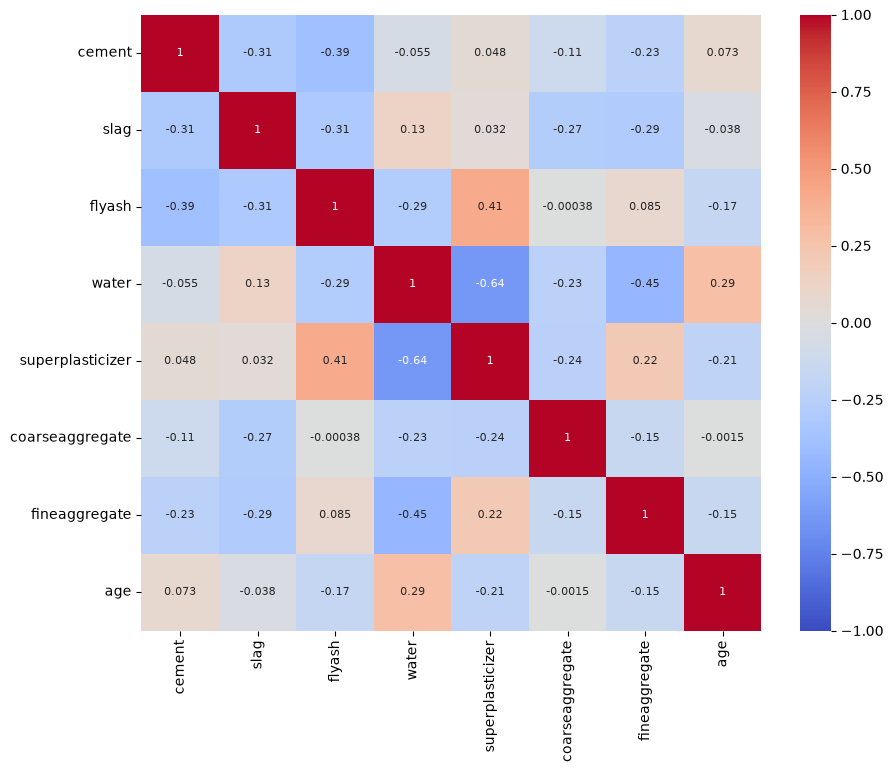

In [11]:
## Visualize the correlation between any two columns as a heatmap.
# What do you see from the correlation heatmap? If several attributes are strongly correlated, collinearity could be an issue for the regression analysis.

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(X_train.corr(), # Visualize the correlation matrix of X_train
            annot = True, # Show correlation coefficients 
            annot_kws={'size':8}, # Size of the correlation coefficients
            vmin=-1, vmax=1, # Values to anchor the colormap
            center= 0, # The value at which to center the colormap when plotting divergent data
            cmap= 'coolwarm', # Color scheme of the heatmap
            ax=ax); # Axes in which to draw the plot; otherwise, use the currently active Axes.

### How many features should we extract/select?

Text(0, 0.5, 'ratio of cumulative variance explained')

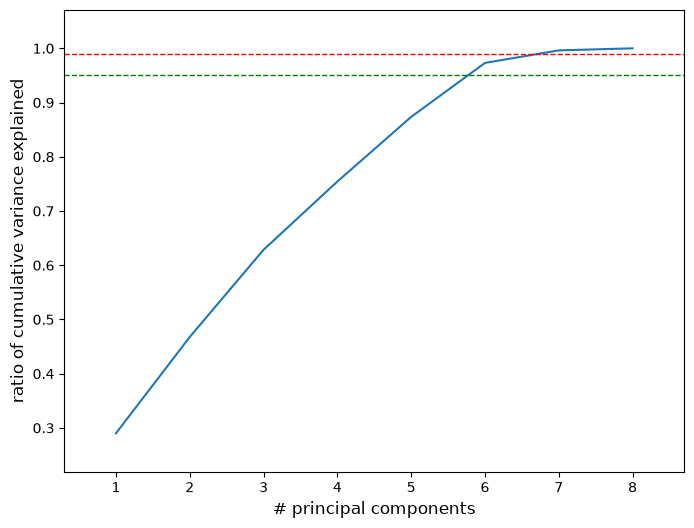

In [12]:
# PCA analysis

pca = PCA(n_components=8)
pca.fit(StandardScaler().fit_transform(X_train))

fig, ax = plt.subplots( figsize=(8,6))
ax.plot(range(1,9),np.cumsum(pca.explained_variance_ratio_))
ax.axhline(y = 0.99, c='r', linewidth =1, linestyle='--')
ax.axhline(y = 0.95, c='g', linewidth =1, linestyle='--' )
plt.margins(0.1)
ax.set_xlabel('# principal components',fontsize=12)
ax.set_ylabel('ratio of cumulative variance explained',fontsize=12)

#plt.savefig('PCA')
# Six principal components explain over 95% of the data variance. We could use the top six components, but 6 and 8 are not very different. 
## Feature extraction is more important for high-dimensional input data.

### Extract Features using PCA

In [13]:
# Apply PCA to transform attribute data into their principal components
Fr_train=pca.transform(StandardScaler().fit_transform(X_train)) # Transform the training data into PCs
Fr_test=pca.transform(StandardScaler().fit_transform(X_test)) # Transform the testing data into PCs

### Exploratory Data Analysis of Extracted PCs

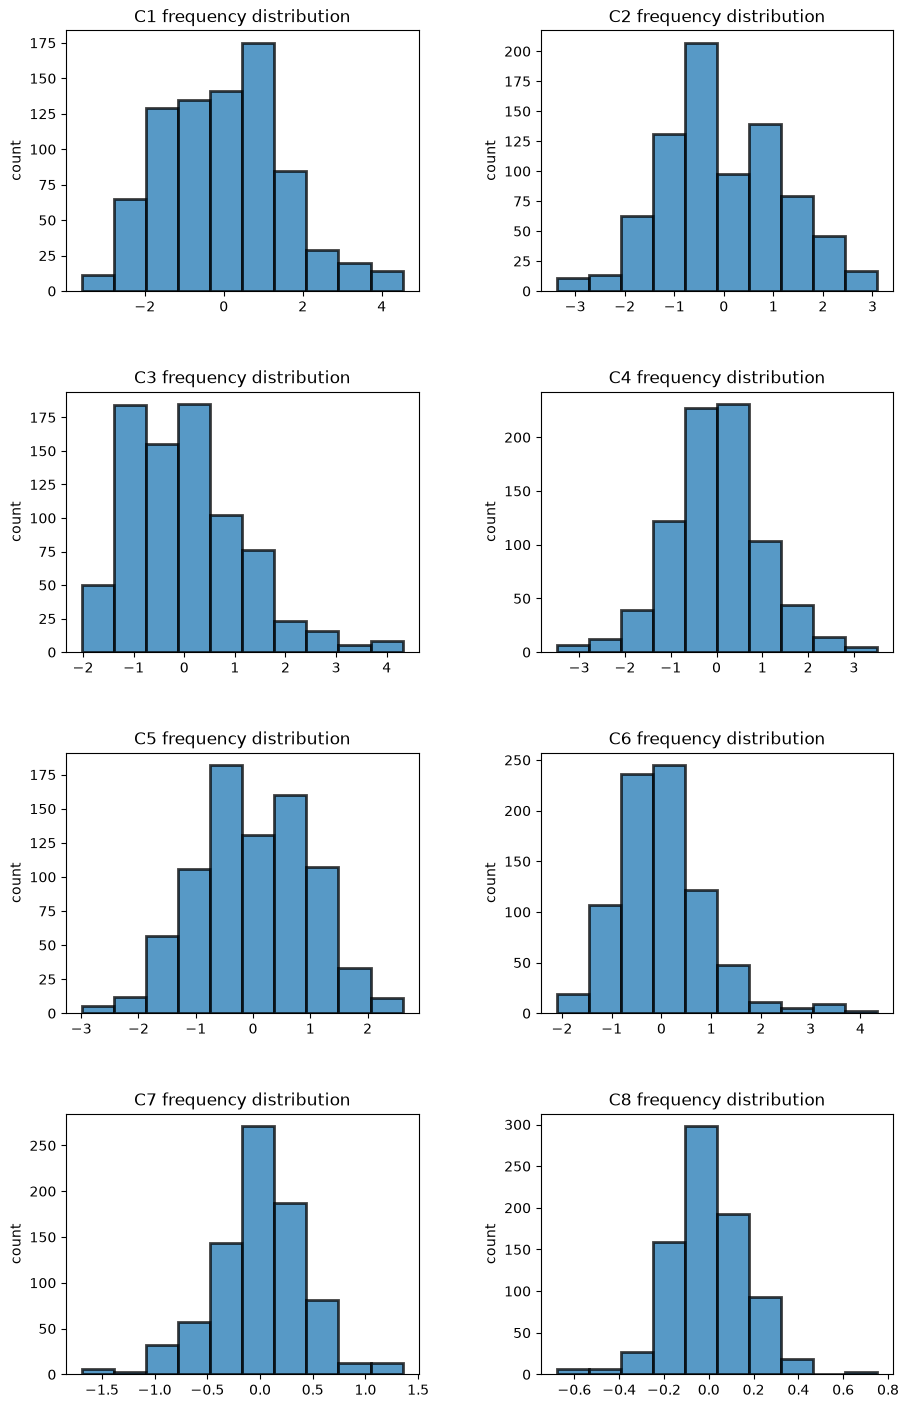

In [14]:
# Frequency distributions of PC features
plt.figure(figsize=(10,15))
for i in range(0,N):
  plt.subplot(4,2,(i)+1)
  plt.hist(x=Fr_train[:,i],alpha=0.75,edgecolor='black',linewidth=2)
  plt.title('C'f'{i+1} frequency distribution',fontsize=12)
  plt.ylabel('count')
  plt.tight_layout(pad=4.0)
  plt.grid(False)
plt.show()

## Define metrics for evaluating goodness-of-fit

In [15]:
# Assemble model overall goodness-of-fit metrics on training data
def print_selection(model, Fr, Y, M, N, rsp_type="numr"):
    # rsp_type: default value is "numr" for numerical response; "cgtr" is for categorical response

    if rsp_type=="numr":
        LogL = (-M/2*np.log(2*np.pi)-M*np.log(np.sqrt(metrics.mean_squared_error(Y, model.predict(Fr))* M/(M-N-1)))-(M-N-1)/2) # correction on 09/15/2026 MSE in sklearn is not the same as MSE in our lecture notes
        AIC = -2*LogL+2*(1+N)
        BIC = -2*LogL+np.log(M)*(1+N)
        r2_train = cross_val_score(model, Fr, Y, cv =5, scoring = 'r2').mean()
        adj_r2_train = 1 - (1 - r2_train) * ((M - 1) / (M - N - 1))
        print(f"AIC:{AIC:,.0f}")
        print(f"BIC:{BIC:,.0f}")
        print(f'The average R squared value for training: {r2_train*100 :.2f}%')
        print(f'The average adjusted R squared value for training: {adj_r2_train*100 :.2f}%')
    
    elif rsp_type=="cagr":
        acc_train = cross_val_score(model, Fr, Y, cv =5, scoring = 'accuracy').mean()
        print(f'The average accuracy for training: {acc_train*100 :.2f}%')
    
    else:
        print('wrong type: {numr: numerical, cagr: categorical} ')


In [16]:
# Assemble model performance metrics together
def print_evaluate(true, predicted, rsp_type="numr"):
# rsp_type: default value is "numr" for numerical response; "cgtr" is for categorical response
    from sklearn import metrics
    from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve
    
    if rsp_type=="numr":
        mae = metrics.mean_absolute_error(true, predicted)
        mse = metrics.mean_squared_error(true, predicted)
        rmse = np.sqrt(mse)
        r_squared = metrics.r2_score(true, predicted)
        #return mae, mse, rmse, r2_square
        print(f'MAE: {mae:.2f}')
        print(f'MSE: {mse:.2f}')
        print(f'RMSE: {rmse:.2f}')
        print(f'R Squared: {r_squared*100:.2f}%')
        print('__________________________________')
        
    elif rsp_type=="cagr":
        cls_report = metrics.classification_report(true, predicted)
        acc = metrics.accuracy_score(true, predicted)
        print(f'classification accuracy: {acc*100:.2f}%')
        print(f'classification report:{cls_report}\n')

        class_names = np.unique(true).astype(str).tolist()
        fig, ax = plt.subplots(figsize=(5,3))
        tick_marks = np.arange(len(class_names))
        cm = confusion_matrix(true,predicted) # confusion matrix
        sns.heatmap(pd.DataFrame(cm), 
                    annot=True, 
                    cmap="YlGnBu" ,
                    fmt='g',
                    xticklabels=class_names,
                    yticklabels=class_names)
    
        ax.xaxis.set_label_position("top")
    
        plt.tight_layout()
        plt.title('Confusion matrix', y=1.1)
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.show();
    else:
        print('wrong type: "numr"-numerical, "cagr"-categorical')

## Linear Regression Model

### Ordinary Least Squares

In [17]:
# Call the linear regressor and fit the linear regression model

lr_model = LinearRegression().fit(Fr_train,y_str_train)

In [18]:
# Define coefficient names
Coef_names = [f"w{i}" for i in range(N+1)]
Coef_names

['w0', 'w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w7', 'w8']

In [19]:
# Regression coefficients, w0, w1,..., w8
coeff_df = pd.DataFrame(np.append(lr_model.intercept_,lr_model.coef_), 
                        index = Coef_names,
                        columns = ['Coefficient'])
coeff_df.round(3)

,Coefficient
w0,35.666
w1,-0.156
w2,-0.468
w3,7.375
w4,1.329
w5,-5.037
w6,7.749
w7,-7.370
w8,11.752


In [20]:
## We can also find regression coefficients using linear algebra
Z = np.append(np.ones([M,1]),Fr_train,1)  # eq.(9)
w_hat = np.linalg.inv(Z.T @ Z) @ Z.T @ y_str_train  # eq.(16)
coef_lr = pd.DataFrame(w_hat,
                       index = Coef_names,
                       columns=['Coefficient'])
coef_lr.round(3)

,Coefficient
w0,35.666
w1,-0.156
w2,-0.468
w3,7.375
w4,1.329
w5,-5.037
w6,7.749
w7,-7.370
w8,11.752


In [21]:
# We can also provide the interval estimates for the coefficients 

# Calculate standard errors of regression coefficients using linear algebra
residuals = y_str_train - lr_model.predict(Fr_train) # eq.(18)
residual_sum_of_squares = residuals.T @ residuals 
sigma_squared_hat = residual_sum_of_squares / (M-N-1) # This is the point estimate of sigma_epsilon^2. See eq. (19)

var_w_hat =np.linalg.inv(Z.T @ Z)*sigma_squared_hat # eq.(21)

se = np.sqrt(np.diag(var_w_hat)) # eq. (22)

# Determine the t-value
from scipy.stats import t
alpha = 0.05 # Level of significance. You can change this to your own value
t_val = t.ppf(1-alpha/2,M-N-1) # t-value at 1 - alpha/2

# Margin of error
me = se * t_val # eq. (23)

In [22]:
# Display the (1-alpha) confidence interval estimates for regression coefficients w0, w1, ..., w8
lr_coefficients_CI=pd.DataFrame(np.append(w_hat.reshape(N+1,1),me.reshape(N+1,1),1),
                                index = Coef_names,
                                columns=['Coefficient','Margin of error'])
print(f'the {1-alpha} interval estimates for the regression coefficients are:\n')
lr_coefficients_CI.round(3)

# The 95% interval estimates for w1 and w2 contain zero, indicating that C1 and C2 might not be useful predictors 

the 0.95 interval estimates for the regression coefficients are:



,Coefficient,Margin of error
w0,35.666,0.722
w1,-0.156,0.474
w2,-0.468,0.605
w3,7.375,0.636
w4,1.329,0.719
w5,-5.037,0.739
w6,7.749,0.809
w7,-7.370,1.680
w8,11.752,4.150


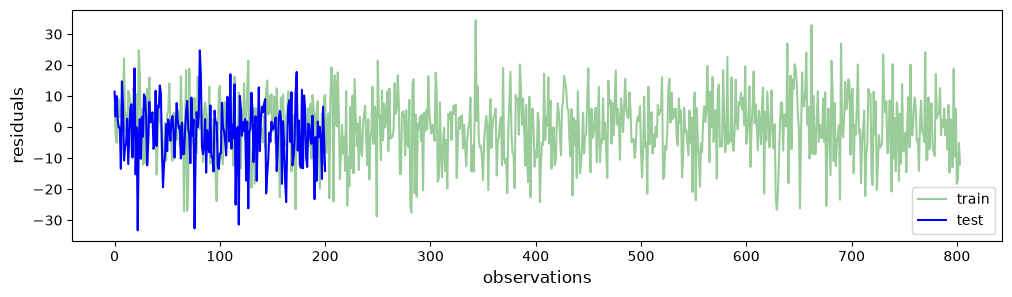

In [23]:
# Visually check the independence of residuals
# The independence of residuals seems to hold

plt.figure(figsize=(12,3))
plt.plot(y_str_train-lr_model.predict(Fr_train),c='g',alpha=0.4) # Residuals calculated using the training dataset
plt.plot(y_str_test-lr_model.predict(Fr_test),c='b') # Residuals calculated using the testing dataset
plt.xlabel('observations',fontsize=12)
plt.ylabel('residuals',fontsize=12)
plt.legend(['train','test'])
plt.show()

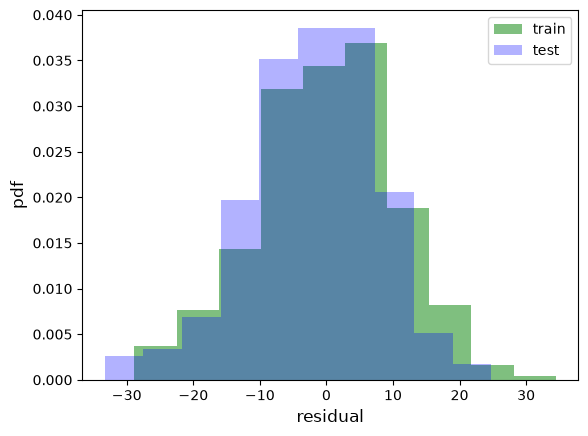

In [24]:
# Examine the distribution of residuals
# The normality of residuals seems to hold

plt.hist(y_str_train-lr_model.predict(Fr_train),density=True,color='g',alpha=0.5) # Distribution of residuals - training dataset
plt.hist(y_str_test-lr_model.predict(Fr_test),density=True,color='b',alpha=0.3) # Distribution of residuals - testing dataset
plt.legend(['train','test'])
plt.xlabel('residual',fontsize=12)
plt.ylabel('pdf',fontsize=12)
plt.show()

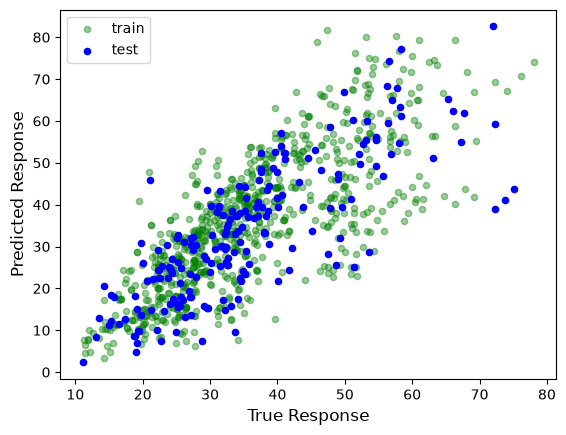

In [25]:
# Show the correlation between the predicted response and the true response

plt.scatter(lr_model.predict(Fr_train),y_str_train,c='g',s=20,alpha=0.4) # True vs. predicted response - training dataset
plt.scatter(lr_model.predict(Fr_test),y_str_test,c='b',s=20) # # True vs. predicted response - testing dataset
plt.xlabel('True Response',fontsize=12)
plt.ylabel('Predicted Response',fontsize=12)
plt.legend(['train','test'])
plt.show()

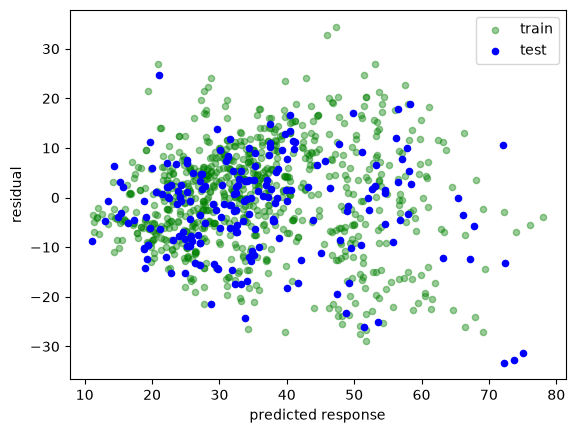

In [26]:
# Plot residuals against the predicted response to check the homogeneity of residuals
plt.scatter(lr_model.predict(Fr_train), y_str_train-lr_model.predict(Fr_train),c='g',s=20,alpha=0.4)  # Residual vs. predicted response - training dataset
plt.scatter(lr_model.predict(Fr_test), y_str_test-lr_model.predict(Fr_test),c='b',s=20) # Residual vs. predicted response - testing dataset
plt.legend(['train','test'])
plt.xlabel('predicted response')
plt.ylabel('residual')
plt.show()

# The residual distribution seems to increase with the predicted response, indicating that the homogeneity of residuals might not hold

In [27]:
# Overall goodness-of-fit in training 
print_selection(lr_model, Fr_train, y_str_train, M, N)

AIC:6,060
BIC:6,102
The average R squared value for training: 56.41%
The average adjusted R squared value for training: 55.97%


In [28]:
# Evaluate the model performance on the testing dataset
print_evaluate(y_str_test, lr_model.predict(Fr_test))

MAE: 7.62
MSE: 99.14
RMSE: 9.96
R Squared: 61.57%
__________________________________


In [81]:
# Univariate feature selection works by selecting the best features based on univariate statistical tests. 
# It can be seen as a preprocessing step to an estimator.
# SelectKBest(metric, k) selects features according to the k highest scores.
FeatureSelection = SelectKBest(f_regression, k=6)
Fr_train_sel=FeatureSelection.fit_transform(Fr_train, y_str_train) # selected features
Sel_Index=FeatureSelection.get_support() # Boolean index indicating the selection
#Sel_Index=[True, False, True, True, True, True,True,True] # manually override the selection result
print('Selected features are:\n',Sel_Index,'\n')

Fr_train_sel=Fr_train[:,Sel_Index]

# Selected features in the test dataset
Fr_test_sel = Fr_test[:,Sel_Index]

n = np.sum(Sel_Index) # Number of attributes

# Fit the model using selected features
lr_model_new = LinearRegression().fit(Fr_train_sel, y_str_train)


# Evaluate the goodness-of-fit of the regression model in training 
print('\nThe model overall goodness-of-fit in training is:')
print_selection(lr_model_new, Fr_train_sel, y_str_train, M, n)


print('\nThe test accuracy is:')
print_evaluate(y_str_test, lr_model_new.predict(Fr_test_sel))

Selected features are:
 [False False  True  True  True  True  True  True] 


The model overall goodness-of-fit in training is:
AIC:6,059
BIC:6,092
The average R squared value for training: 57.25%
The average adjusted R squared value for training: 56.92%

The test accuracy is:
MAE: 7.70
MSE: 100.99
RMSE: 10.05
R Squared: 60.85%
__________________________________


### Lasso

In [30]:
# Fit a Lasso regression model
lassor_model = Lasso(alpha=0.5).fit(Fr_train,y_str_train)

In [31]:
# Regression coefficients
coeff_lassor = pd.DataFrame(np.append(lassor_model.intercept_,lassor_model.coef_),
                            index = Coef_names,
                            columns = ['Coefficient'])
coeff_lassor.round(3)

,Coefficient
w0,35.666
w1,-0.000
w2,-0.116
w3,6.986
w4,0.832
w5,-4.513
w6,7.121
w7,-4.661
w8,0.000


In [32]:
# Evaluate the goodness-of-fit of the regression model in training 
print('\nThe model overall goodness-of-fit in training is:')
print_selection(lassor_model, Fr_train, y_str_train, M, N)

# Evaluate the model on the test dataset
print('\nThe test accuracy is:')
print_evaluate(y_str_test, lassor_model.predict(Fr_test))


The model overall goodness-of-fit in training is:
AIC:6,109
BIC:6,152
The average R squared value for training: 54.55%
The average adjusted R squared value for training: 54.09%

The test accuracy is:
MAE: 7.95
MSE: 102.56
RMSE: 10.13
R Squared: 60.24%
__________________________________


### Ridge

In [33]:
# Fit a Ridge regression model
Ridge_model = Ridge(alpha=0.5).fit(Fr_train,y_str_train)


In [34]:
# Regression coefficients
coeff_Ridge = pd.DataFrame(np.append(Ridge_model.intercept_,Ridge_model.coef_), 
                           index = Coef_names,
                           columns=['Coefficient'])
coeff_Ridge.round(3)

,Coefficient
w0,35.666
w1,-0.156
w2,-0.468
w3,7.371
w4,1.328
w5,-5.034
w6,7.742
w7,-7.345
w8,11.515


In [35]:
# Evaluate the goodness-of-fit of the regression model in training 
print('\nThe model overall goodness-of-fit in training is:')
print_selection(Ridge_model, Fr_train, y_str_train, M, N)

# Evaluate the model on the test dataset
print('\nThe test accuracy is:')
print_evaluate(y_str_test, Ridge_model.predict(Fr_test))


The model overall goodness-of-fit in training is:
AIC:6,060
BIC:6,102
The average R squared value for training: 56.42%
The average adjusted R squared value for training: 55.98%

The test accuracy is:
MAE: 7.62
MSE: 99.09
RMSE: 9.95
R Squared: 61.59%
__________________________________


### Elastic Net

In [36]:
# Fit Elastic Net regression, which combines both L1 and L2 regularization on regression coefficients

# For l1_ratio = 0 the penalty is an L2 penalty. For l1_ratio = 1 it is an L1
# penalty. For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2

ElasticNet_model = ElasticNet(alpha=0.06,l1_ratio=1).fit(Fr_train,y_str_train)

In [37]:
# Regression coefficients
coeff_enr = pd.DataFrame(np.append(ElasticNet_model.intercept_,ElasticNet_model.coef_), 
                         index = Coef_names, 
                         columns=['Coefficient'])
coeff_enr.round(3)

,Coefficient
w0,35.666
w1,-0.130
w2,-0.426
w3,7.328
w4,1.269
w5,-4.974
w6,7.673
w7,-7.045
w8,9.769


In [38]:
# Evaluate the goodness-of-fit of the regression model in training 
print('\nThe model overall goodness-of-fit in training is:')
print_selection(ElasticNet_model, Fr_train, y_str_train, M, N)

# Evaluate the model on the test dataset
print('\nThe test accuracy is:')
print_evaluate(y_str_test, ElasticNet_model.predict(Fr_test))


The model overall goodness-of-fit in training is:
AIC:6,061
BIC:6,103
The average R squared value for training: 56.45%
The average adjusted R squared value for training: 56.01%

The test accuracy is:
MAE: 7.64
MSE: 98.78
RMSE: 9.94
R Squared: 61.71%
__________________________________


### Fine-Tuning Hyperparameters of Elastic Net Regression

In [ ]:
# Fit Elastic Net regression, which combines both L1 and L2 regularization on regression coefficients

# This parameter can be a list; in that case, the different values are tested by
# cross-validation and the one giving the best prediction score is used.

# Note that a good choice of list of values for l1_ratio is often to put more values
# close to 1 (i.e. Lasso) and less close to 0 (i.e. Ridge), as in
 # [.1, .5, .7, .9, .95, .99, 0.995, 1].
l1_ratios = [.1, .5, .7, .9, .95, .99, .995, 0.999, 1]

# We either choose a list of alpha values or define the number of alphas for each l1_ratio
#alphas = np.arange(0,10.,0.1)

encvr_model = ElasticNetCV(l1_ratio=l1_ratios, # List of l1_ratio values to test
                           cv=5, # Number of folds in cross-validation
                           random_state=5,
                           alphas=100 # Number of alpha values to test
                          ).fit(Fr_train,y_str_train)
print('The selected alpha is', f'{encvr_model.alpha_:.3}','\n')
print('The selected l1 ratio is', f'{encvr_model.l1_ratio_:.3}','\n')

The selected alpha is 0.0582 

The selected l1 ratio is 1.0 



In [40]:
# Regression coefficients
coeff_encvr = pd.DataFrame(np.append(encvr_model.intercept_,encvr_model.coef_), 
                           index = Coef_names, 
                           columns=['Coefficient'])
coeff_encvr.round(3)

,Coefficient
w0,35.666
w1,-0.131
w2,-0.427
w3,7.330
w4,1.271
w5,-4.976
w6,7.675
w7,-7.054
w8,9.827


In [41]:
# Evaluate the goodness-of-fit of the regression model in training 
print('\nThe model overall goodness-of-fit in training is:')
print_selection(encvr_model, Fr_train, y_str_train, M, N)

# Evaluate the model on the test dataset
print('\nThe test accuracy is:')
print_evaluate(y_str_test, encvr_model.predict(Fr_test))


The model overall goodness-of-fit in training is:
AIC:6,061
BIC:6,103
The average R squared value for training: 56.32%
The average adjusted R squared value for training: 55.88%

The test accuracy is:
MAE: 7.64
MSE: 98.79
RMSE: 9.94
R Squared: 61.70%
__________________________________


## Polynomial Linear Model

### Generate polynomial features from predictor variables

In [42]:
# Generate polynomial features
poly_degree = 3
poly_reg = PolynomialFeatures(degree=poly_degree) # If a, b, and c are three features, ab, ac, and bc are degree-2 polynomial features. a^2b, a^2c, b^2a, b^2c, c^2a, c^2b, a^3, b^3, and c^3 are degree-3 polynomial features
X_poly_train= poly_reg.fit_transform(Fr_train) # Transform features into polynomial features
X_poly_test=poly_reg.fit_transform(Fr_test)

### Fine-Tune Elastic Net

In [43]:
l1_ratios = [.1, .5, .7, .9, .95, .99, .995, 0.999, 1]

#plr=ElasticNetCV(l1_ratio=l1_ratios,cv=5,random_state=5,n_alphas=100, max_iter=1000, tol=0.01, fit_intercept=False)
plr_model=ElasticNetCV(l1_ratio=l1_ratios,
                       cv=5,
                       random_state=5,
                       alphas=100, 
                       max_iter=1000, 
                       tol=0.01, 
                       fit_intercept=False
                      ).fit(X_poly_train,y_str_train)

print('The selected alpha is', f'{plr_model.alpha_:.3}','\n')
print('The selected l1 ratio is', f'{plr_model.l1_ratio_:.3}','\n')
## The fine-tuning result suggests that the best model is Lasso regression, that is, linear regression with norm-1 regularization

## If we remove the regularizers, we just use the ordinary linear regression model
#plr_model=LinearRegression().fit(X_poly_train,y_st_train)

The selected alpha is 0.0917 

The selected l1 ratio is 0.999 



In [44]:
# Regression coefficients
coeff_plr = pd.DataFrame(plr_model.coef_, poly_reg.get_feature_names_out(), columns=['Coefficient'])
coeff_plr.round(4)


,Coefficient
1,42.0410
x0,0.7945
x1,-1.2946
x2,4.9130
x3,-1.2470
...,...
x5 x7^2,0.0000
x6^3,-0.0000
x6^2 x7,0.0000
x6 x7^2,0.0000


In [45]:
# Count the number of regression coefficients that are estimated as zero
print('The number of polynomial attributes dropped is:',np.sum([coeff_plr==0]))


The number of polynomial attributes dropped is: 70


In [82]:
# number of predictors
n = np.sum([coeff_plr!=0])-1

# MSE
sigma_squared_hat  = (y_str_train - plr_model.predict(X_poly_train)).T @ (y_str_train - plr_model.predict(X_poly_train))/(M-n-1)
# Estimate of the standard deviation of residuals
var_w_hat_poly =np.linalg.inv(X_poly_train.T @ X_poly_train)*sigma_squared_hat

# t-value
from scipy.stats import t
alpha = 0.05 # Level of significance. You can change this to your own value
t_val = t.ppf(1-alpha/2,M-n-1) # t-value at 1 - alpha/2

# Margin of error
me_poly=np.sqrt(np.diag(var_w_hat_poly))*t_val

# Boolean index that identifies selected polynomial terms
Sel_Index = coeff_plr['Coefficient'] != 0

# Display the (1-alpha) confidence interval estimates for regression coefficients w0, w1, ..., w8
polycoefficients_CI=pd.DataFrame(np.append(coeff_plr[Sel_Index],me_poly[Sel_Index].reshape(n+1,1),1),
                                columns=['Coefficients','Margin of error'])
print(f'the {1-alpha} confidence interval for the regression coefficients are:\n')
polycoefficients_CI.round(3)

the 0.95 confidence interval for the regression coefficients are:



,Coefficients,Margin of error
0,42.041,4.405
1,0.795,3.045
2,-1.295,2.759
3,4.913,3.334
4,-1.247,3.299
...,...,...
90,-0.679,0.987
91,-0.365,1.599
92,0.363,8.630
93,0.094,1.575


In [47]:
# Evaluate the goodness-of-fit of the regression model in training 
print('\nThe model overall goodness-of-fit in training is:')
print_selection(plr_model, X_poly_train, y_str_train, M, n)

# Evaluate the model on the test dataset
print('\nThe test accuracy is:')
print_evaluate(y_str_test, plr_model.predict(X_poly_test))


The model overall goodness-of-fit in training is:
AIC:5,347
BIC:5,792
The average R squared value for training: 77.83%
The average adjusted R squared value for training: 74.89%

The test accuracy is:
MAE: 4.94
MSE: 39.62
RMSE: 6.29
R Squared: 84.64%
__________________________________


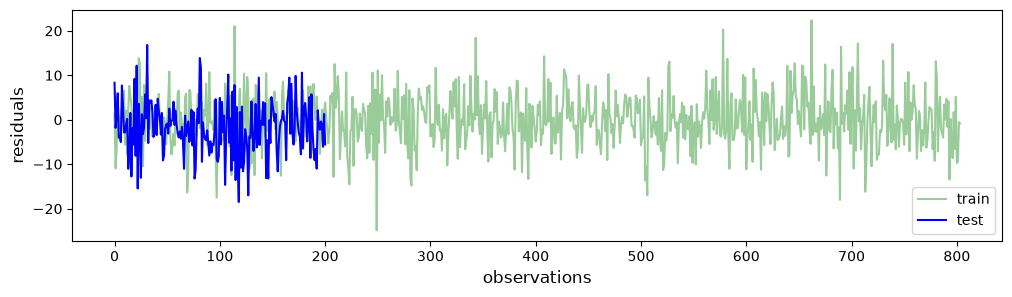

In [48]:
# Visually check the independence of residuals
plt.figure(figsize=(12,3))
plt.plot(y_str_train-plr_model.predict(X_poly_train),c='g',alpha=0.4) # Residuals calculated using the training dataset
plt.plot(y_str_test-plr_model.predict(X_poly_test),c='b') # Residuals calculated using the testing dataset
plt.xlabel('observations',fontsize=12)
plt.ylabel('residuals',fontsize=12)
plt.legend(['train','test'])
plt.show()

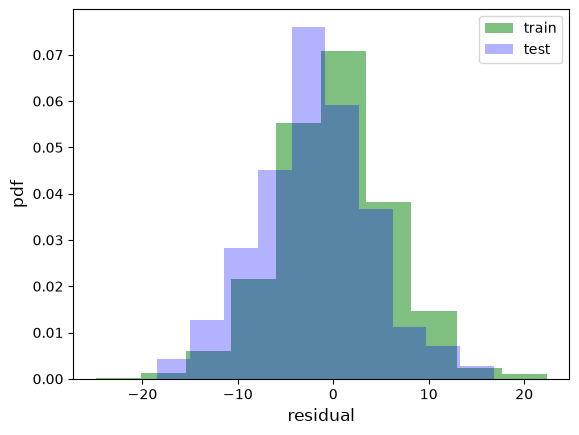

In [49]:
# Examine the distribution of residuals
plt.hist(y_str_train-plr_model.predict(X_poly_train),density=True,color='g',alpha=0.5) # Distribution of residuals - training dataset
plt.hist(y_str_test-plr_model.predict(X_poly_test),density=True,color='b',alpha=0.3) # Distribution of residuals - testing dataset
plt.legend(['train','test'])
plt.xlabel('residual',fontsize=12)
plt.ylabel('pdf',fontsize=12)
plt.show()

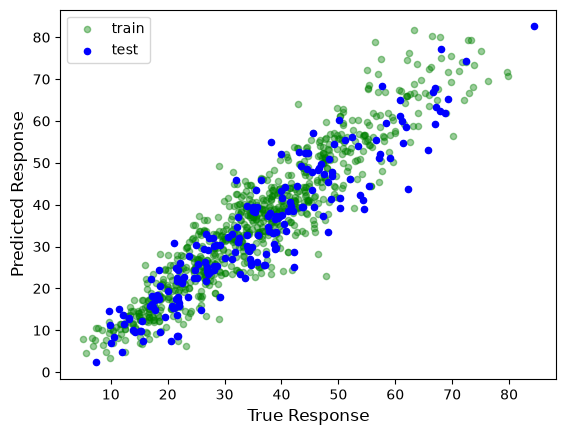

In [50]:
# Show the correlation between the predicted response and the true response
plt.scatter(plr_model.predict(X_poly_train),y_str_train,c='g',s=20,alpha=0.4) # True vs. predicted response - training dataset
plt.scatter(plr_model.predict(X_poly_test),y_str_test,c='b',s=20) # # True vs. predicted response - testing dataset
plt.xlabel('True Response',fontsize=12)
plt.ylabel('Predicted Response',fontsize=12)
plt.legend(['train','test'])
plt.show()

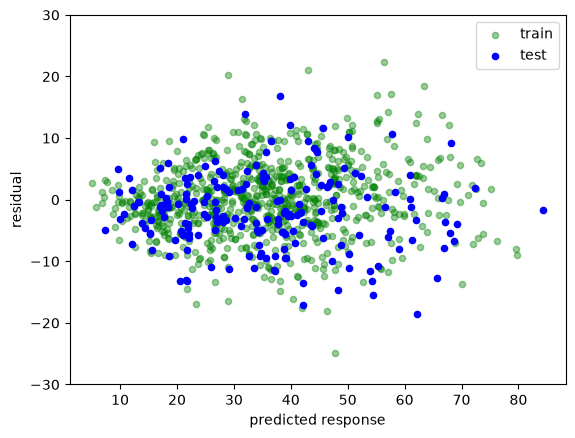

In [51]:
# Plot residuals against the predicted response to check the homogeneity of residuals
plt.scatter(plr_model.predict(X_poly_train), y_str_train-plr_model.predict(X_poly_train),c='g',s=20,alpha=0.4)  # Residual vs. predicted response - training dataset
plt.scatter(plr_model.predict(X_poly_test), y_str_test-plr_model.predict(X_poly_test),c='b',s=20) # Residual vs. predicted response - testing dataset
plt.ylim([-30,30])
plt.legend(['train','test'])
plt.xlabel('predicted response')
plt.ylabel('residual')
plt.show()

## Binary Logistic Regression

We fit a binary logistic regression model to predict whether a concrete block will develop a defect after one year of use, using the extracted PCs as predictors.

In [52]:
# Let's check whether the classes are imbalanced. If they are imbalanced, we may consider
# using class weights when defining the loss function
uniqueVals, counts = np.unique(y_dft_train,return_counts=True)
print(f'The sizes for the classes {uniqueVals} are:{counts}\n')
print(counts)

The sizes for the classes [0. 1.] are:[575 229]

[575 229]


In [53]:
# fit a logistic regression model
blr_model=LogisticRegression(
    class_weight={0:1,1:1.5},
    solver='sag'
).fit(Fr_train,y_dft_train) # If using cross-entropy loss, multi_class='multinomial'


In [54]:
# Regression coefficients
coeff_blr = pd.DataFrame(np.append(blr_model.intercept_,blr_model.coef_), 
                         index = Coef_names, 
                         columns = ['Coefficient'])
coeff_blr.round(3)

,Coefficient
w0,-3.252
w1,-1.644
w2,0.923
w3,-1.609
w4,2.284
w5,2.062
w6,-5.267
w7,1.083
w8,-2.021


In [55]:
# Training accuracy
print_selection(blr_model, Fr_train, y_dft_train, M, N,"cagr")

The average accuracy for training: 88.55%


classification accuracy: 89.55%
classification report:              precision    recall  f1-score   support

         0.0       0.94      0.90      0.92       136
         1.0       0.81      0.88      0.84        65

    accuracy                           0.90       201
   macro avg       0.88      0.89      0.88       201
weighted avg       0.90      0.90      0.90       201




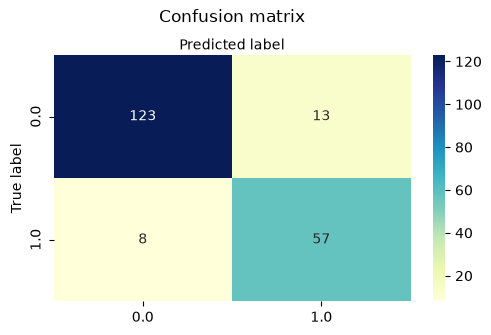

In [56]:
# Regression model test performance 
print_evaluate(y_dft_test,blr_model.predict(Fr_test),"cagr")

In [57]:
# Prediction on the testing dataset
y_test_pred = blr_model.predict(Fr_test) # Prediction of y_i's
p_test_pred = blr_model.predict_proba(Fr_test) # The probabilities that y_i is in classes 0 and 1, respectively

## Multinomial Logistic Regression

In [58]:
digits = datasets.load_digits() # Load data
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [59]:
X, y = digits.data, digits.target # digits.data contains predictors, and digits.target is the response with 10 classes (0, 1, ..., 9)

# Parameters
n_prd = X.shape[1] # Number of observations
print('The number of predictors is:', n_prd,'\n')
n_classes = len(np.unique(y)) # Number of classes
print('The number of classes is:',n_classes,'\n')
obs = len(y)
print('The number of data points is:',obs, '\n')

random_state = 4 # Make the result replicable


X_norm = StandardScaler().fit_transform(X) # Data normalization

# Split data (both features X and target y) into training and testing datasets.
# We use training data to learn model parameters.
# We use test data to assess the performance of prediction
X_train, X_test, y_train, y_test = train_test_split(
                                                    X_norm, y, test_size=0.2, stratify=y,
                                                    random_state=random_state)


The number of predictors is: 64 

The number of classes is: 10 

The number of data points is: 1797 



In [60]:
# Fit a multinomial logistic regression
mlr=LogisticRegression(solver='saga',
                       penalty='elasticnet', 
                       l1_ratio=0.3, 
                       max_iter=2000)
mlr_model = mlr.fit(X_train,y_train)

/opt/miniconda3/envs/CIV555/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [61]:
# Point estimates of regression coefficients
coeff_mlr = pd.DataFrame(np.insert(mlr_model.coef_.T,0,mlr_model.intercept_,axis=0)) # Insert mlr_model.intercept_ before row 0
#coeff_mlr = pd.DataFrame(np.append(mlr_model.intercept_,mlr_model.coef_), columns=['Coefficient'])
print('regression coefficients are:\n')
print(coeff_mlr.round(4))

print('The number of zero-valued coefficients is:', (n_prd+1)*n_classes-np.count_nonzero(coeff_mlr))

regression coefficients are:

         0       1       2       3       4       5       6       7       8  \
0  -0.1872 -0.4996 -0.2621  0.0608 -0.3229  0.2917 -0.3071  0.0383  1.4073   
1   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
2   0.0000  0.0000  0.0000  0.1275 -0.0957  0.2917  0.0000  0.0000 -0.1049   
3   0.0000  0.0000  0.0499 -0.1779 -0.4184  1.0677 -0.2937  0.2422  0.0578   
4   0.0000  0.2084  0.0535  0.0588 -0.9208 -0.2390 -0.1400  0.0593 -0.1530   
..     ...     ...     ...     ...     ...     ...     ...     ...     ...   
60  0.1797 -0.1195  0.2108  0.1186 -0.5493  0.6811 -0.2942 -0.4759  0.1807   
61  0.0000  0.3226  0.0310  0.0000 -0.3669 -0.0087  0.0000 -0.8747  0.4908   
62 -0.0746  0.6615  0.6556  0.0000 -0.5191  0.0000  0.6573 -0.8243 -0.2681   
63 -0.0583  0.3088  0.6590  0.0218 -0.0553 -0.6677  0.0500 -0.1191 -0.1528   
64  0.0000  0.4116  0.3937 -0.1552  0.0000 -0.0391 -0.0853  0.0000  0.0000   

         9  
0  -0.2191  
1   0.0

In [62]:
# Training accuracy
print_selection(mlr_model, X_train, y_train, M, N,"cagr")

/opt/miniconda3/envs/CIV555/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/CIV555/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/envs/CIV555/lib/

The average accuracy for training: 96.66%


classification accuracy: 98.06%
classification report:              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        37
           2       0.97      1.00      0.99        35
           3       1.00      0.97      0.99        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        36
           6       1.00      0.94      0.97        36
           7       0.97      1.00      0.99        36
           8       0.94      0.91      0.93        35
           9       1.00      1.00      1.00        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360




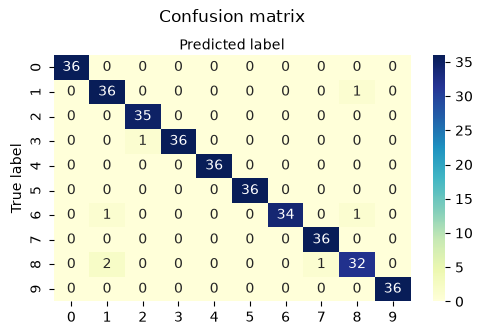

In [63]:
# Regression model test performance 
print_evaluate(y_test,mlr_model.predict(X_test),"cagr")

## Ordinal Logistic Regression

### Diamonds dataset


The Diamond.csv dataset used here is a revised version of the diamonds.csv dataset from Kaggle. It contains prices and other attributes for almost 54,000 diamonds.

Attributes

carat: weight of the diamond (0.2--5.01)

cut: quality of the cut (Fair, Good, Very Good, Premium, Ideal)

color: diamond color, from J (worst) to D (best)

clarity: a measure of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))

depth: total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)

table: width of the top of the diamond relative to its widest point (43--95)

price: price in US dollars (\$326--\$18,823)

volume: x * y * z mm^3 (0--20116.23)

In [64]:
# Load data
Diamond = pd.read_csv('Data/Diamond.csv')
Diamond.head()

,carat,cut,color,clarity,depth,table,price,volume
0,0.23,Ideal,E,SI2,61.5,55.0,326,38.20
1,0.21,Premium,E,SI1,59.8,61.0,326,34.51
2,0.23,Good,E,VS1,56.9,65.0,327,38.08
3,0.29,Premium,I,VS2,62.4,58.0,334,46.72
4,0.31,Good,J,SI2,63.3,58.0,335,51.92


In [65]:
# Check the data types of the dataset
Diamond.info()


<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   volume   53940 non-null  float64
dtypes: float64(4), int64(1), str(3)
memory usage: 3.3 MB


In [66]:
# statsmodels requires that the response is a categorical variable with ordered classes.
# Therefore, we define the response as an ordered categorical variable
cat_type = pd.CategoricalDtype(categories=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], ordered=True)
Diamond['cut'] = Diamond['cut'].astype(cat_type)
Diamond['cut'].dtype

CategoricalDtype(categories=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], ordered=True, categories_dtype=str)

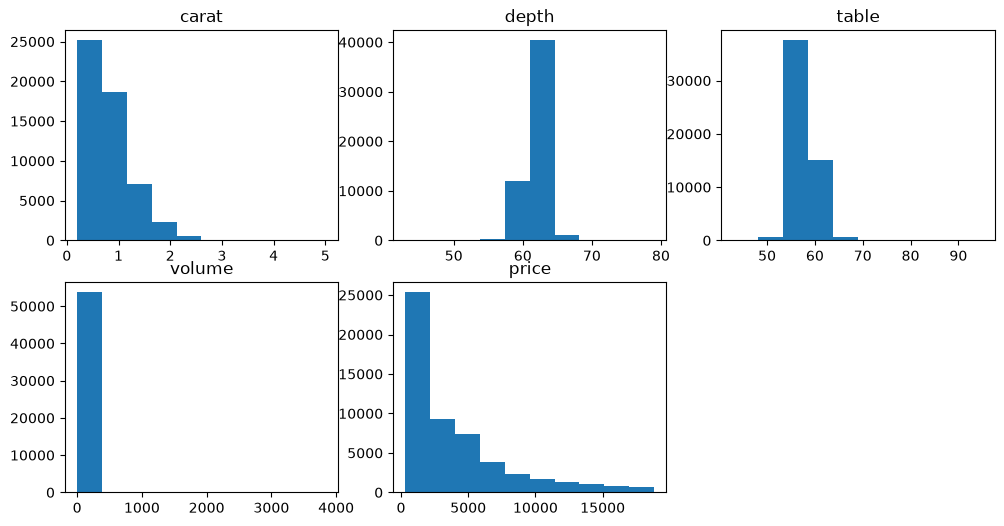

In [67]:
# Show the histograms of numerical predictors
# Several of them are not normally distributed, and their scales are quite different.
# We may normalize these predictors

plt.figure(figsize=(12, 6))

plt.subplot(2,3,1)
plt.hist(Diamond.carat)
plt.title('carat')

plt.subplot(2,3,2)
plt.hist(Diamond.depth)
plt.title('depth')

plt.subplot(2,3,3)
plt.hist(Diamond.table)
plt.title('table')

plt.subplot(2,3,4)
plt.hist(Diamond.volume)
plt.title('volume')

plt.subplot(2,3,5)
plt.hist(Diamond.price)
plt.title('price')

plt.show()

In [68]:
# Show the frequency distributions of categorical predictors and the response
# If categorical variables are used as predictors, we may recode them as dummy variables
print(Diamond[['cut']].value_counts(),'\n')
print(Diamond[['color']].value_counts(),'\n')
print(Diamond[['clarity']].value_counts())

cut      
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64 

color
G        11292
E         9797
F         9542
H         8304
D         6775
I         5422
J         2808
Name: count, dtype: int64 

clarity
SI1        13065
VS2        12258
SI2         9194
VS1         8171
VVS2        5066
VVS1        3655
IF          1790
I1           741
Name: count, dtype: int64


In [69]:
# Normalize the quantitative predictors
temp=StandardScaler().fit_transform(Diamond[['carat','depth','table','price','volume']])
Diamond=pd.concat([pd.DataFrame(temp,columns=['carat','depth','table','price','volume']),Diamond[['cut','color','clarity']]],axis=1)
Diamond.head()

,carat,depth,table,price,volume,cut,color,clarity
0,-1.198168,-0.174092,-1.099672,-0.904095,-1.171321,Ideal,E,SI2
1,-1.240361,-1.360738,1.585529,-0.904095,-1.218480,Premium,E,SI1
2,-1.198168,-3.385019,3.375663,-0.903844,-1.172854,Good,E,VS1
3,-1.071587,0.454133,0.242928,-0.902090,-1.062431,Premium,I,VS2
4,-1.029394,1.082358,0.242928,-0.901839,-0.995973,Good,J,SI2


In [70]:
# Code categorical predictors as dummy variables
Diamond = pd.get_dummies(Diamond, columns=['color','clarity'],dtype=float)
Diamond.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   carat         53940 non-null  float64 
 1   depth         53940 non-null  float64 
 2   table         53940 non-null  float64 
 3   price         53940 non-null  float64 
 4   volume        53940 non-null  float64 
 5   cut           53940 non-null  category
 6   color_D       53940 non-null  float64 
 7   color_E       53940 non-null  float64 
 8   color_F       53940 non-null  float64 
 9   color_G       53940 non-null  float64 
 10  color_H       53940 non-null  float64 
 11  color_I       53940 non-null  float64 
 12  color_J       53940 non-null  float64 
 13  clarity_I1    53940 non-null  float64 
 14  clarity_IF    53940 non-null  float64 
 15  clarity_SI1   53940 non-null  float64 
 16  clarity_SI2   53940 non-null  float64 
 17  clarity_VS1   53940 non-null  float64 
 18  clarity_VS2   539

### Fitting an Ordinal Logistic Regression Model

In [71]:
# Our hypothesis is that cut can be inferred from the physical features of
# diamonds, including carat, table, depth, and volume
X =Diamond[['carat','table','depth','volume']]
y = Diamond['cut']
random_state = 4
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,
                                                    random_state=random_state)

In [72]:
ordlr_model = OrderedModel(y_train,X_train,distr='logit')
result_ordlr = ordlr_model.fit(method='bfgs')
result_ordlr.summary()

Optimization terminated successfully.
         Current function value: 1.167117
         Iterations: 32
         Function evaluations: 33
         Gradient evaluations: 33


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                    cut   Log-Likelihood:                -50363.
Model:                   OrderedModel   AIC:                         1.007e+05
Method:            Maximum Likelihood   BIC:                         1.008e+05
Date:                Wed, 16 Sep 2026                                         
Time:                        07:33:06                                         
No. Observations:               43152                                         
Df Residuals:                   43144                                         
Df Model:                           4                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
carat                -0.4007      0.114     -3.513      0.000      -0.624      -0.177
table                -1.3351      0.012   -111.965      0.000      -1.358      -1.312
depth                -0.8960      0.012    -75.184      0.000      -0.919      -0.873
volume                0.3414      0.116      2.935      0.003       0.113       0.569
Fair/Good            -4.4689      0.033   -133.768      0.000      -4.534      -4.403
Good/Very Good        0.6294      0.016     39.705      0.000       0.598       0.660
Very Good/Premium     0.5170      0.010     53.887      0.000       0.498       0.536
Premium/Ideal         0.3441      0.009     39.562      0.000       0.327       0.361
=====================================================================================
"""

In [73]:
# Estimates of p_{i,k} = p(y_i=class k|x_i, hat_w, beta_k)
p = result_ordlr.model.predict(result_ordlr.params, X_test)
p

array([[0.02256752, 0.10845957, 0.31546436, 0.32129112, 0.23221743],
       [0.00650932, 0.0345237 , 0.14523742, 0.29780019, 0.51592936],
       [0.00296401, 0.01608078, 0.07504571, 0.20450542, 0.70140409],
       ...,
       [0.1421426 , 0.37757279, 0.33298674, 0.10685738, 0.04044049],
       [0.03204848, 0.14573715, 0.35855723, 0.28948147, 0.17417567],
       [0.01329658, 0.06759066, 0.23921504, 0.33857102, 0.3413267 ]],
      shape=(10788, 5))

In [74]:
# Estimates of y_i = argmax_k (y_{i,1}, ..., y_{i,k}, ..., y_{i,K})
# That is, the class with the highest probability is the prediction for y_i
y_test_pred=p.argmax(1)
y_test_pred

array([3, 4, 4, ..., 1, 2, 4], shape=(10788,))

In [75]:
# We convert the ordered categories of the ground truth into numbers
# In this way, the ground truth y_test and the prediction y_test_pred are in the same data type
# This makes the following evaluation easier
mapping = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
y_test_num = np.vectorize(mapping.get)(y_test)

In [76]:
# Let's take a look at the counts by class in y_test and y_test_pred
class_names=['Fair', 'Good', 'Very Good', 'Premium','Ideal']

unique_values, counts = np.unique(y_test_num, return_counts=True)
print(f'The true volumes of class {class_names} are')
print(counts,'\n')

unique_values, counts = np.unique(y_test_pred, return_counts=True)
print(f'The predicted volumes of class {class_names} are')
print(counts)

The true volumes of class ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'] are
[ 322  981 2417 2758 4310] 

The predicted volumes of class ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'] are
[  95  390 2543 1409 6351]


### Evaluation

In [77]:
# Calculate accuracy
acc = np.sum(y_test_num==y_test_pred)/len(y_test_num)
acc.round(2)

np.float64(0.53)

<Figure size 640x480 with 0 Axes>

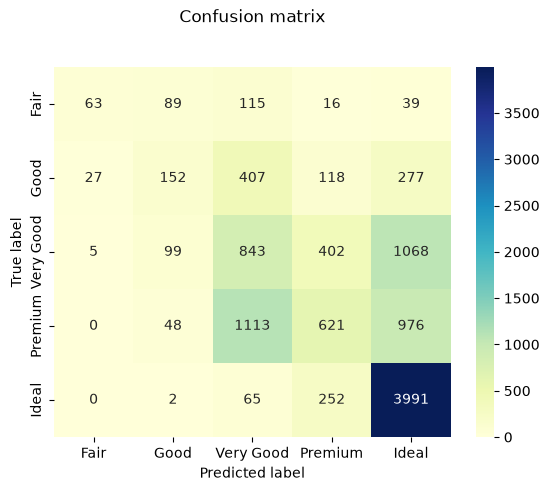

In [78]:
# confusion matrix
cnf_matrix=metrics.confusion_matrix(y_test_num, y_test_pred)

# Visualize the confusion matrix
plt.tight_layout()
fig, ax = plt.subplots()
class_names=['Fair', 'Good', 'Very Good', 'Premium','Ideal'] # Names of classes
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g',ax=ax,xticklabels=class_names, yticklabels=class_names)
tick_marks = np.arange(len(class_names))
ax.xaxis.set_label_position("bottom")
plt.title('Confusion matrix', y=1.1)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()